# Knowledge Distillation: Llama-3.1-8B → Llama-3.2-1B
**CS 455 Term Project** — Ali Kumral, Revna Demirkale

---
## MUST RUN FIRST — run the cell below after every runtime restart
Everything else in this notebook depends on it. It is safe to re-run at any time.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# MUST RUN FIRST — run after every runtime restart before anything else
# ═══════════════════════════════════════════════════════════════════════
import os, sys

# ── constants (change these if your paths differ) ──────────────────────
REPO_URL   = "https://github.com/alikumral/Knowledge-Distillation-Transferring-Mathematical-Reasoning"
REPO_NAME  = "Knowledge-Distillation-Transferring-Mathematical-Reasoning"
REPO_PATH  = f"/content/{REPO_NAME}"
DRIVE_HOME = "/content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning"

# ── 1. GPU memory allocator (prevents fragmentation OOM) ───────────────
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# ── 2. Clone (first run) or pull latest (after restart) ────────────────
if not os.path.exists(REPO_PATH):
    print("Cloning repo...")
    os.system(f"git clone {REPO_URL}")
else:
    print("Repo exists, pulling latest changes...")
    os.system(f"git -C {REPO_PATH} pull")
    # Clear stale module cache so pulled changes take effect in this kernel.
    # (git pull updates files on disk; without this, Python keeps using the
    #  old in-memory version of every mathdistill module.)
    for _k in list(sys.modules.keys()):
        if "mathdistill" in _k:
            del sys.modules[_k]
    print("Module cache cleared.")


# ── 3. cd + make mathdistill importable ────────────────────────────────
os.chdir(REPO_PATH)
SRC_PATH = os.path.join(REPO_PATH, "src")
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

# ── 4. Install Python deps (fast after first run; deps are pip-cached) ─
os.system("pip install -q -e . -r requirements.txt")

# ── 5. Mount Google Drive ──────────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive", force_remount=False)
os.environ["MATHDISTILL_HOME"] = DRIVE_HOME
os.makedirs(DRIVE_HOME, exist_ok=True)

# ── 6. Hugging Face login ──────────────────────────────────────────────
from google.colab import userdata
from huggingface_hub import login
login(token=userdata.get("HF_TOKEN"), add_to_git_credential=False)

# ── 7. Summary ─────────────────────────────────────────────────────────
import torch
gpu = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "⚠ NO GPU — switch runtime"
print(f"\n{'='*55}")
print(f"  GPU:       {gpu}")
print(f"  VRAM:      {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB" if torch.cuda.is_available() else "")
print(f"  Repo:      {os.getcwd()}")
print(f"  Artifacts: {os.environ['MATHDISTILL_HOME']}")
print(f"{'='*55}")

Repo exists, pulling latest changes...
Module cache cleared.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

  GPU:       NVIDIA A100-SXM4-40GB
  VRAM:      42.4 GB
  Repo:      /content/Knowledge-Distillation-Transferring-Mathematical-Reasoning
  Artifacts: /content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning


---
## Smoke test
**Do NOT run this before Stage 1 (generation).** It loads both models into VRAM and even after `del model` there is enough fragmentation to OOM the 8B generation. Skip this cell in normal use — it already passed.

In [ ]:
import torch
from mathdistill.utils import load_config
from mathdistill.models import load_model_4bit, load_tokenizer, render_prompt
from mathdistill.prompts import build_messages
from mathdistill.answers import extract_pred_number

tcfg = load_config("configs/teacher_gen.yaml")
q = ("Natalia sold clips to 48 friends in April, and half as many in May. "
     "How many clips did she sell altogether?")

for model_id in [tcfg["model_id"], "meta-llama/Llama-3.2-1B-Instruct"]:
    print("=" * 60, "\nLoading", model_id)
    tok = load_tokenizer(model_id)
    model = load_model_4bit(model_id, tcfg["quantization"])
    enc = tok(render_prompt(tok, build_messages(q)), return_tensors="pt").to(model.device)
    out = model.generate(**enc, max_new_tokens=256, do_sample=False, pad_token_id=tok.pad_token_id)
    text = tok.decode(out[0, enc["input_ids"].shape[1]:], skip_special_tokens=True)
    print(text)
    print(">> extracted:", extract_pred_number(text), "(expected 72)")
    del model
    torch.cuda.empty_cache()

Loading meta-llama/Llama-3.1-8B-Instruct


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

To find the total number of clips Natalia sold, we need to add the number of clips she sold in April and May.

In April, she sold 48 clips.
In May, she sold half as many clips, which is 48 / 2 = 24 clips.

Total clips sold = 48 (April) + 24 (May) = 72 clips.

The final answer is: 72
>> extracted: 72 (expected 72)


---
## Stage 1 — Teacher CoT Generation
Runs Llama-3.1-8B (4-bit) over the GSM8K train split, sampling `k=4` chain-of-thought traces per problem. Writes to Drive incrementally — **resumable** if the session drops.

**Pilot first** (`PILOT = True`): runs on 30 problems (~3 min) to validate throughput and VRAM before the full ~6h run. Check the log says `LIMIT set -> pilot mode: first 30 problems only`.

In [ ]:
from mathdistill.generate import generate_teacher_traces
from mathdistill.utils import load_config

PILOT = False  # True = 30 problems (~3 min to validate). False = full 7,473 problems.
PASS  = 2      # ← change to 0, 1, or 2 for each separate generation pass

cfg = load_config("configs/teacher_gen.yaml")
cfg["pass_id"] = PASS
cfg["batch_size"] = 256   # safe on A100 (40GB); keep at 16 for T4/V100/P100
if PILOT:
    cfg["limit"] = 30

print(f"Starting pass {PASS} | pilot={PILOT} | batch_size={cfg['batch_size']} | k={cfg['generation']['k_samples']}")
generate_teacher_traces(cfg, load_config("configs/data.yaml"))

Starting pass 2 | pilot=False | batch_size=256 | k=1


README.md:   0%|          | 0.00/7.93k [00:00<?, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

...

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

2026-05-30 09:45:36,817 | INFO | generate | Pass 2 | generating for 7443 / 7473 problems (k=1, batch_size=256)
INFO:generate:Pass 2 | generating for 7443 / 7473 problems (k=1, batch_size=256)
2026-05-30 09:46:34,933 | INFO | generate | Pass 2 | batch 0-256 done (256 rows written)
INFO:generate:Pass 2 | batch 0-256 done (256 rows written)
2026-05-30 09:47:35,731 | INFO | generate | Pass 2 | batch 256-512 done (256 rows written)
INFO:generate:Pass 2 | batch 256-512 done (256 rows written)
2026-05-30 09:48:36,634 | INFO | generate | Pass 2 | batch 512-768 done (256 rows written)
INFO:generate:Pass 2 | batch 512-768 done (256 rows written)
2026-05-30 09:49:36,830 | INFO | generate | Pass 2 | batch 768-1024 done (256 rows written)
INFO:generate:Pass 2 | batch 768-1024 done (256 rows written)
2026-05-30 09:50:39,344 | INFO | generate | Pass 2 | batch 1024-1280 done (256 rows written)
INFO:generate:Pass 2 | batch 1024-1280 done (256 rows written)
2026-05-30 09:51:38,464 | INFO | generate | Pa

PosixPath('/content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning/traces/teacher_traces.jsonl')

---
## Stage 2 — Rejection Sampling & Build SFT Datasets
Filters teacher traces to those matching the gold answer, reports acceptance stats (the **Risk-1 check**), and writes the three SFT datasets: `gold`, `teacher_1`, `teacher_3`. CPU-only — no GPU needed.

In [ ]:
import json
from mathdistill.reject import rejection_sample, acceptance_stats, build_all_sft_datasets
from mathdistill.utils import artifact_path, load_config

traces_path   = artifact_path("traces", "teacher_traces.jsonl")
accepted_path = artifact_path("sft", "accepted.jsonl")

rejection_sample(traces_path, accepted_path)
stats = acceptance_stats(accepted_path)
print(json.dumps(stats, indent=2))

build_all_sft_datasets(accepted_path, load_config("configs/data.yaml"))

2026-05-30 10:33:35,267 | INFO | reject | Accepted 18287 / 22449 traces (81.5%) -> /content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning/sft/accepted.jsonl
INFO:reject:Accepted 18287 / 22449 traces (81.5%) -> /content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning/sft/accepted.jsonl
2026-05-30 10:33:35,417 | INFO | reject | Stats: {'n_accepted_traces': 18287, 'n_problems_with_ge1': 6922, 'n_problems_with_ge3': 5081, 'mean_traces_per_covered_problem': 2.6418665125686216}
INFO:reject:Stats: {'n_accepted_traces': 18287, 'n_problems_with_ge1': 6922, 'n_problems_with_ge3': 5081, 'mean_traces_per_covered_problem': 2.6418665125686216}


{
  "n_accepted_traces": 18287,
  "n_problems_with_ge1": 6922,
  "n_problems_with_ge3": 5081,
  "mean_traces_per_covered_problem": 2.6418665125686216
}


2026-05-30 10:33:37,261 | INFO | reject | SFT dataset 'gold': 7473 records -> /content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning/sft/gold.jsonl
INFO:reject:SFT dataset 'gold': 7473 records -> /content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning/sft/gold.jsonl
2026-05-30 10:33:37,418 | INFO | reject | SFT dataset 'teacher_1': 6922 records -> /content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning/sft/teacher_1.jsonl
INFO:reject:SFT dataset 'teacher_1': 6922 records -> /content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning/sft/teacher_1.jsonl
2026-05-30 10:33:37,807 | INFO | reject | SFT dataset 'teacher_3': 18263 records -> /content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning/sft/teacher_3.jsonl
INFO:reject:SFT dataset 'teacher_3': 18263 records -> /content/d

{'gold': PosixPath('/content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning/sft/gold.jsonl'),
 'teacher_1': PosixPath('/content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning/sft/teacher_1.jsonl'),
 'teacher_3': PosixPath('/content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning/sft/teacher_3.jsonl')}

---
## Stage 3 — QLoRA Fine-tuning
Trains one (condition, seed) adapter. Change `CONFIG` and `SEED` per run. Spread runs across sessions to stay within Colab's GPU quota (~2h per run).

**Run pilot first** with a small subset to confirm loss decreases before a full 2h run.

In [ ]:
from mathdistill.train import train_one
from mathdistill.utils import load_config

CONFIG = "configs/train_teacher_1.yaml"   # train_teacher_1 | train_teacher_3 | train_gold
SEED   = 0                                # 0, 1, 2

train_one(load_config(CONFIG), load_config("configs/data.yaml"), seed=SEED)

2026-06-03 11:28:13,399 | INFO | train | Loaded SFT dataset 'teacher_1': 6922 records
INFO:train:Loaded SFT dataset 'teacher_1': 6922 records


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
2026-06-03 11:28:18,263 | INFO | train | SFTConfig: 'max_seq_length' not in this TRL version — skipping
INFO:train:SFTConfig: 'max_seq_length' not in this TRL version — skipping
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
2026-06-03 11:28:18,287 | WARNING | train | Completion-only collator failed (cannot import name 'DataCollatorForCompletionOnlyLM' from 'trl' (/usr/local/lib/python3.12/dist-packages/trl/__init__.py)) — training on full sequence. Note this in the report.
2026-06-03 11:28:18,289 | INFO | train | Training condition=teacher_1 seed=0 -> /content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning/adapters/teacher_1/seed0
INFO:train:Training conditi

Tokenizing train dataset:   0%|          | 0/6922 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


Step,Training Loss
10,1.735579
20,1.066600
30,0.628202
40,0.606323
50,0.569887
60,0.564422
70,0.562973
80,0.530622
90,0.543824
100,0.504771


2026-06-03 11:46:12,050 | INFO | train | Saved adapter -> /content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning/adapters/teacher_1/seed0
INFO:train:Saved adapter -> /content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning/adapters/teacher_1/seed0


PosixPath('/content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning/adapters/teacher_1/seed0')

In [ ]:
from mathdistill.train import train_one
from mathdistill.utils import load_config

CONFIG = "configs/train_gold.yaml"   # train_teacher_1 | train_teacher_3 | train_gold
SEED   = 0                                # 0, 1, 2

train_one(load_config(CONFIG), load_config("configs/data.yaml"), seed=SEED)

2026-06-03 12:05:05,146 | INFO | train | Loaded SFT dataset 'gold': 7473 records
INFO:train:Loaded SFT dataset 'gold': 7473 records


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
2026-06-03 12:05:10,230 | INFO | train | SFTConfig: 'max_seq_length' not in this TRL version — skipping
INFO:train:SFTConfig: 'max_seq_length' not in this TRL version — skipping
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
2026-06-03 12:05:10,255 | WARNING | train | Completion-only collator failed (cannot import name 'DataCollatorForCompletionOnlyLM' from 'trl' (/usr/local/lib/python3.12/dist-packages/trl/__init__.py)) — training on full sequence. Note this in the report.
2026-06-03 12:05:10,256 | INFO | train | Training condition=gold seed=0 -> /content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning/adapters/gold/seed0
INFO:train:Training condition=gold se

Tokenizing train dataset:   0%|          | 0/7473 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


Step,Training Loss
10,2.531145
20,1.586103
30,0.968751
40,0.862019
50,0.871657
60,0.831793
70,0.807807
80,0.782170
90,0.782003
100,0.763468


2026-06-03 12:24:54,753 | INFO | train | Saved adapter -> /content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning/adapters/gold/seed0
INFO:train:Saved adapter -> /content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning/adapters/gold/seed0


PosixPath('/content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning/adapters/gold/seed0')

In [ ]:
from mathdistill.train import train_one
from mathdistill.utils import load_config

CONFIG = "configs/train_teacher_3.yaml"   # train_teacher_1 | train_teacher_3 | train_gold
SEED   = 0                                # 0, 1, 2

train_one(load_config(CONFIG), load_config("configs/data.yaml"), seed=SEED)

2026-06-03 12:25:55,307 | INFO | train | Loaded SFT dataset 'teacher_3': 18263 records
INFO:train:Loaded SFT dataset 'teacher_3': 18263 records


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
2026-06-03 12:26:01,386 | INFO | train | SFTConfig: 'max_seq_length' not in this TRL version — skipping
INFO:train:SFTConfig: 'max_seq_length' not in this TRL version — skipping
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
2026-06-03 12:26:01,410 | WARNING | train | Completion-only collator failed (cannot import name 'DataCollatorForCompletionOnlyLM' from 'trl' (/usr/local/lib/python3.12/dist-packages/trl/__init__.py)) — training on full sequence. Note this in the report.
2026-06-03 12:26:01,412 | INFO | train | Training condition=teacher_3 seed=0 -> /content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning/adapters/teacher_3/seed0
INFO:train:Training conditi

Tokenizing train dataset:   0%|          | 0/18263 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


Step,Training Loss
10,1.853028
20,1.427266
30,0.970896
40,0.649928
50,0.585581
60,0.560288
70,0.563640
80,0.557198
90,0.530876
100,0.563562


Step,Training Loss
10,1.853028
20,1.427266
30,0.970896
40,0.649928
50,0.585581
60,0.560288
70,0.563640
80,0.557198
90,0.530876
100,0.563562


2026-06-03 13:15:05,335 | INFO | train | Saved adapter -> /content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning/adapters/teacher_3/seed0
INFO:train:Saved adapter -> /content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning/adapters/teacher_3/seed0


PosixPath('/content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning/adapters/teacher_3/seed0')

---
## Stage 4 — Evaluation
Evaluates each condition (greedy decoding) on GSM8K test + MATH-200, reports accuracy with 95% bootstrap CIs.

In [ ]:
import sys
for _k in list(sys.modules.keys()):
    if "mathdistill" in _k:
        del sys.modules[_k]

STUDENT = "meta-llama/Llama-3.2-1B-Instruct"
TEACHER = "meta-llama/Llama-3.1-8B-Instruct"

# (i) zero-shot 1B — no adapter
!python scripts/run_eval.py --model-id {STUDENT} --name zeroshot

Loading weights:   2% 3/146 [00:00<00:07, 17.99it/s, Materializing param=model.layers.0.mlp.down_proj.weight]/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100% 146/146 [00:00<00:00, 196.11it/s, Materializing param=model.norm.weight]
README.md: 100% 7.93k/7.93k [00:00<00:00, 9.06MB/s]
main/train-00000-of-00001.parquet: 100% 2.31M/2.31M [00:01<00:00, 2.20MB/s]
main/test-00000-of-00001.parquet: 100% 419k/419k [00:00<00:00, 1.36MB/s]
Generating train split: 100% 7473/7473 [00:00<00:00, 462308.20 examples/s]
Generating test split: 100% 1319/1319 [00:00<00:00, 283242.22 examples/s]
The following generation flags are not valid and may be ignored: ['top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
2026-06-03 13:55:14,391 | INFO | evaluate | Scored 16 / 1319
2026-

In [ ]:
# (ii) gold CoT, seed 0
!python scripts/run_eval.py --model-id {STUDENT} --adapter adapters/gold/seed0 --name gold_seed0

Loading weights:   2% 3/146 [00:00<00:08, 17.85it/s, Materializing param=model.layers.0.mlp.down_proj.weight]/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100% 146/146 [00:00<00:00, 196.28it/s, Materializing param=model.norm.weight]
2026-06-03 14:30:48,292 | INFO | evaluate | Attached adapter: /content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning/adapters/gold/seed0
The following generation flags are not valid and may be ignored: ['top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
2026-06-03 14:31:02,864 | INFO | evaluate | Scored 16 / 1319
2026-06-03 14:31:12,401 | INFO | evaluate | Scored 32 / 1319
2026-06-03 14:31:23,777 | INFO | evaluate | Scored 48 / 1319
2026-06-03 14:31:36,978 | INFO | evaluate | Scored 

In [ ]:
# (iii) teacher_1, seed 0
!python scripts/run_eval.py --model-id {STUDENT} --adapter adapters/teacher_1/seed0 --name teacher_1_seed0

Loading weights:   2% 3/146 [00:00<00:08, 16.73it/s, Materializing param=model.layers.0.mlp.down_proj.weight]/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100% 146/146 [00:00<00:00, 181.10it/s, Materializing param=model.norm.weight]
2026-06-03 15:08:53,249 | INFO | evaluate | Attached adapter: /content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning/adapters/teacher_1/seed0
The following generation flags are not valid and may be ignored: ['top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
2026-06-03 15:09:22,337 | INFO | evaluate | Scored 16 / 1319
2026-06-03 15:09:47,647 | INFO | evaluate | Scored 32 / 1319
2026-06-03 15:10:09,804 | INFO | evaluate | Scored 48 / 1319
2026-06-03 15:10:34,022 | INFO | evaluate | Sc

In [ ]:
# (iv) teacher_3, seed 0
!python scripts/run_eval.py --model-id {STUDENT} --adapter adapters/teacher_3/seed0 --name teacher_3_seed0

Loading weights:   2% 3/146 [00:00<00:08, 17.37it/s, Materializing param=model.layers.0.mlp.down_proj.weight]/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100% 146/146 [00:00<00:00, 182.51it/s, Materializing param=model.norm.weight]
2026-06-03 16:16:43,365 | INFO | evaluate | Attached adapter: /content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning/adapters/teacher_3/seed0
The following generation flags are not valid and may be ignored: ['top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
2026-06-03 16:17:10,061 | INFO | evaluate | Scored 16 / 1319
2026-06-03 16:17:52,294 | INFO | evaluate | Scored 32 / 1319
2026-06-03 16:18:33,808 | INFO | evaluate | Scored 48 / 1319
2026-06-03 16:19:03,829 | INFO | evaluate | Sc

In [ ]:
# (v) 8B teacher upper bound
!python scripts/run_eval.py --model-id {TEACHER} --name teache

config.json: 100% 855/855 [00:00<00:00, 3.58MB/s]
tokenizer_config.json: 100% 55.4k/55.4k [00:00<00:00, 27.9MB/s]
tokenizer.json: 100% 9.09M/9.09M [00:00<00:00, 10.9MB/s]
special_tokens_map.json: 100% 296/296 [00:00<00:00, 1.38MB/s]
model.safetensors.index.json: 100% 23.9k/23.9k [00:00<00:00, 52.3MB/s]
Fetching 4 files: 100% 4/4 [00:44<00:00, 11.01s/it]
Download complete: 100% 16.1G/16.1G [00:44<00:00, 364MB/s]
Loading weights:   1% 4/291 [00:00<00:54,  5.31it/s, Materializing param=model.layers.0.mlp.down_proj.weight]/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100% 291/291 [00:04<00:00, 65.20it/s, Materializing param=model.norm.weight] 
generation_config.json: 100% 184/184 [00:00<00:00, 884kB/s]
The following generation flags are not valid and may be ignored: ['to

In [ ]:
# Aggregate all prediction files into a results table.
import glob, os, pandas as pd
from mathdistill.utils import read_jsonl
from mathdistill.metrics import accuracy, bootstrap_ci

pred_dir = os.path.join(os.environ["MATHDISTILL_HOME"], "results", "predictions")
rows = []
for path in sorted(glob.glob(os.path.join(pred_dir, "*.jsonl"))):
    data = read_jsonl(path)
    correct = [r["correct"] for r in data]
    lo, hi = bootstrap_ci(correct)
    rows.append({"condition": os.path.basename(path).replace(".jsonl", ""),
                 "n": len(correct), "acc": round(accuracy(correct), 4),
                 "ci_lo": round(lo, 4), "ci_hi": round(hi, 4)})
pd.DataFrame(rows)

,condition,n,acc,ci_lo,ci_hi
0,gold_seed0_gsm8k,1319,0.3374,0.3124,0.3632
1,gold_seed0_math,167,0.2096,0.1497,0.2754
2,teache_gsm8k,1319,0.8287,0.8082,0.8491
3,teache_math,167,0.5389,0.4611,0.6168
4,teacher_1_seed0_gsm8k,1319,0.4678,0.4412,0.4951
5,teacher_1_seed0_math,167,0.2695,0.2036,0.3353
6,teacher_3_seed0_gsm8k,1319,0.4337,0.4071,0.4610
7,teacher_3_seed0_math,167,0.2695,0.2036,0.3353
8,zeroshot_gsm8k,1319,0.3806,0.3548,0.4064
9,zeroshot_math,167,0.3353,0.2635,0.4072


## Stage 5 — Analysis

In [ ]:
# ── Step 1: Load all predictions and GSM8K test metadata ─────────────────────
import os, numpy as np, pandas as pd
from datasets import load_dataset
from mathdistill.utils import read_jsonl

PRED = os.path.join(os.environ["MATHDISTILL_HOME"], "results", "predictions")
FIG  = os.path.join(os.environ["MATHDISTILL_HOME"], "results", "figures")
os.makedirs(FIG, exist_ok=True)

# Load GSM8K test split (needed for questions, gold answers, difficulty buckets)
test_data = list(load_dataset("openai/gsm8k", "main")["test"])
N = len(test_data)  # 1319

# Gold CoT length (word count of solution text before ####) → proxy for difficulty
gold_cot_lengths = [
    len(row["answer"].split("####")[0].strip().split())
    for row in test_data
]
sorted_len = sorted(gold_cot_lengths)
t1, t2 = sorted_len[N // 3], sorted_len[2 * N // 3]

def difficulty(length):
    if length <= t1:   return "easy"
    elif length <= t2: return "medium"
    else:              return "hard"

diff_labels = [difficulty(l) for l in gold_cot_lengths]
print(f"Difficulty thresholds (by gold CoT word count):")
print(f"  easy   : ≤ {t1} words")
print(f"  medium : {t1+1}–{t2} words")
print(f"  hard   : > {t2} words")
print(f"  counts : {diff_labels.count('easy')} / {diff_labels.count('medium')} / {diff_labels.count('hard')}")

# Load all 5 GSM8K prediction files into a dict keyed by condition name
# Note: teacher was saved as "teache" (typo in --name flag, one letter short)
CONDS = {
    "zero_shot":  "zeroshot_gsm8k.jsonl",
    "gold":       "gold_seed0_gsm8k.jsonl",
    "teacher_1":  "teacher_1_seed0_gsm8k.jsonl",
    "teacher_3":  "teacher_3_seed0_gsm8k.jsonl",
    "teacher_8B": "teache_gsm8k.jsonl",
}

preds = {}
for name, fname in CONDS.items():
    path = os.path.join(PRED, fname)
    rows = read_jsonl(path)
    preds[name] = {r["problem_id"]: r for r in rows}
    print(f"  {name}: {len(rows)} predictions loaded")

Difficulty thresholds (by gold CoT word count):
  easy   : ≤ 36 words
  medium : 37–57 words
  hard   : > 57 words
  counts : 452 / 431 / 436
  zero_shot: 1319 predictions loaded
  gold: 1319 predictions loaded
  teacher_1: 1319 predictions loaded
  teacher_3: 1319 predictions loaded
  teacher_8B: 1319 predictions loaded


### Analysis 1 — Per-difficulty Error Analysis (Step 2)
Accuracy bucketed by gold-CoT length tertiles (easy / medium / hard).
Shows where the student gains most from distillation and where it still trails the teacher.

── Accuracy by difficulty bucket ──
 condition   easy  medium   hard  overall
 zero_shot 0.5088  0.3968 0.2317   0.3806
      gold 0.5022  0.3271 0.1766   0.3374
 teacher_1 0.6261  0.4455 0.3257   0.4678
 teacher_3 0.5841  0.4176 0.2936   0.4337
teacher_8B 0.8894  0.8677 0.7271   0.8287


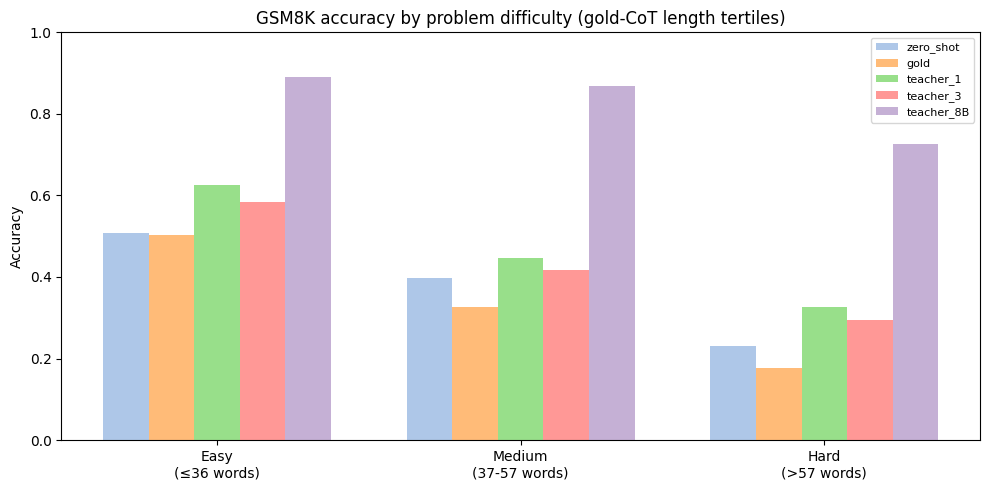

Saved -> F1_difficulty_accuracy.png


In [ ]:
import matplotlib.pyplot as plt

# ── Per-difficulty accuracy table ─────────────────────────────────────────────
rows = []
for cond_name in CONDS:
    cond_preds = preds[cond_name]
    buckets = {"easy": [], "medium": [], "hard": [], "overall": []}
    for pid in range(N):
        if pid not in cond_preds:
            continue
        correct = cond_preds[pid]["correct"]
        buckets[diff_labels[pid]].append(correct)
        buckets["overall"].append(correct)
    row = {"condition": cond_name}
    for b in ["easy", "medium", "hard", "overall"]:
        vals = buckets[b]
        row[b] = round(sum(vals) / len(vals), 4) if vals else float("nan")
    rows.append(row)

df_diff = pd.DataFrame(rows)
print("── Accuracy by difficulty bucket ──")
print(df_diff.to_string(index=False))

# ── Figure F1: grouped bar chart ──────────────────────────────────────────────
x = np.arange(3)
buckets_plot = ["easy", "medium", "hard"]
width = 0.15
fig, ax = plt.subplots(figsize=(10, 5))

colors = ["#aec7e8", "#ffbb78", "#98df8a", "#ff9896", "#c5b0d5"]
for i, (_, row) in enumerate(df_diff.iterrows()):
    vals = [row[b] for b in buckets_plot]
    ax.bar(x + i * width, vals, width, label=row["condition"], color=colors[i])

ax.set_xticks(x + 2 * width)
ax.set_xticklabels(["Easy\n(≤%d words)" % t1,
                    "Medium\n(%d-%d words)" % (t1+1, t2),
                    "Hard\n(>%d words)" % t2])
ax.set_ylabel("Accuracy")
ax.set_title("GSM8K accuracy by problem difficulty (gold-CoT length tertiles)")
ax.legend(fontsize=8)
ax.set_ylim(0, 1)
ax.axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.savefig(os.path.join(FIG, "F1_difficulty_accuracy.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> F1_difficulty_accuracy.png")

### Analysis 2 — Generation-length Distribution (Step 3)
Reveals verbosity inheritance: distilled models learned to generate longer reasoning chains like the teacher.
This explains the 2× latency increase (teacher_1 vs zero-shot).

── Generation length statistics (tokens) ──
 condition  mean  median   p25   p75   p90  max
 zero_shot 164.5   156.0 125.0 193.0 235.2  512
      gold  77.8    68.0  50.0  94.0 125.0  512
 teacher_1 185.2   172.0 142.0 214.0 262.0  512
 teacher_3 187.9   174.0 141.0 216.5 263.0  512
teacher_8B 193.6   181.0 143.0 226.0 276.0  512


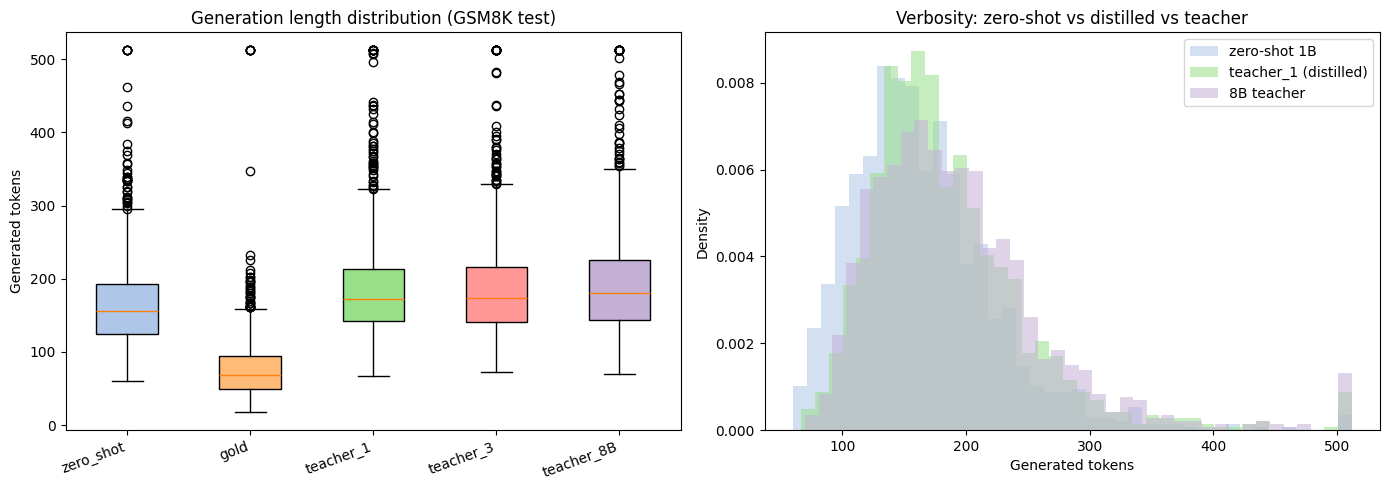

Saved -> F2_generation_lengths.png


In [ ]:
# ── Generation-length statistics ──────────────────────────────────────────────
len_rows = []
all_lengths = {}
for cond_name in CONDS:
    lengths = [r["gen_tokens"] for r in preds[cond_name].values()]
    all_lengths[cond_name] = lengths
    len_rows.append({
        "condition": cond_name,
        "mean":   round(float(np.mean(lengths)), 1),
        "median": round(float(np.median(lengths)), 1),
        "p25":    round(float(np.percentile(lengths, 25)), 1),
        "p75":    round(float(np.percentile(lengths, 75)), 1),
        "p90":    round(float(np.percentile(lengths, 90)), 1),
        "max":    int(np.max(lengths)),
    })

df_len = pd.DataFrame(len_rows)
print("── Generation length statistics (tokens) ──")
print(df_len.to_string(index=False))

# ── Figure F2: box plots + overlaid histograms ────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
data_plot = [all_lengths[c] for c in CONDS]
bp = ax1.boxplot(data_plot, patch_artist=True, notch=False)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
ax1.set_xticklabels(list(CONDS.keys()), rotation=20, ha="right")
ax1.set_ylabel("Generated tokens")
ax1.set_title("Generation length distribution (GSM8K test)")

# Histogram overlay for zero_shot vs teacher_1 vs teacher_8B (most interesting trio)
for cond, color, label in [
    ("zero_shot",  "#aec7e8", "zero-shot 1B"),
    ("teacher_1",  "#98df8a", "teacher_1 (distilled)"),
    ("teacher_8B", "#c5b0d5", "8B teacher"),
]:
    ax2.hist(all_lengths[cond], bins=40, alpha=0.55, color=color,
             label=label, density=True)
ax2.set_xlabel("Generated tokens")
ax2.set_ylabel("Density")
ax2.set_title("Verbosity: zero-shot vs distilled vs teacher")
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG, "F2_generation_lengths.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> F2_generation_lengths.png")

### Analysis 3 — Qualitative Trace Study (Step 4)
Side-by-side comparison of zero-shot vs teacher_1 on matched problems.
Picks: 2 × teacher_1 wins, 1 × teacher_1 loss, 1 × both correct (style comparison).

In [ ]:
def show_case(pid, label, max_chars=600):
    """Print a formatted comparison case for the report."""
    q   = test_data[pid]["question"]
    ans = test_data[pid]["answer"].split("####")[-1].strip()
    zs  = preds["zero_shot"][pid]
    t1p = preds["teacher_1"][pid]
    sep = "─" * 70
    print(f"\n{'═'*70}")
    print(f"  [{label}]  Problem ID {pid}  |  difficulty: {diff_labels[pid]}")
    print(f"{'═'*70}")
    print(f"QUESTION:  {q}")
    print(f"GOLD ANSWER: {ans}")
    print(sep)
    zs_tag  = "✓" if zs["correct"]  else "✗"
    t1_tag  = "✓" if t1p["correct"] else "✗"
    print(f"ZERO-SHOT {zs_tag} ({zs['gen_tokens']} tokens):\n{zs['completion'][:max_chars]}")
    print(sep)
    print(f"TEACHER_1 {t1_tag} ({t1p['gen_tokens']} tokens):\n{t1p['completion'][:max_chars]}")

# ── Find cases ────────────────────────────────────────────────────────────────
t1_wins  = [pid for pid in range(N) if pid in preds["teacher_1"] and pid in preds["zero_shot"]
             and preds["teacher_1"][pid]["correct"] and not preds["zero_shot"][pid]["correct"]]
t1_losses = [pid for pid in range(N) if pid in preds["teacher_1"] and pid in preds["zero_shot"]
              and not preds["teacher_1"][pid]["correct"] and preds["zero_shot"][pid]["correct"]]
both_correct = [pid for pid in range(N) if pid in preds["teacher_1"] and pid in preds["zero_shot"]
                and preds["teacher_1"][pid]["correct"] and preds["zero_shot"][pid]["correct"]]

print(f"teacher_1 wins  (t1✓ zs✗): {len(t1_wins)}")
print(f"teacher_1 losses (t1✗ zs✓): {len(t1_losses)}")
print(f"Both correct:                {len(both_correct)}")
print(f"Both wrong:                  {N - len(t1_wins) - len(t1_losses) - len(both_correct)}")

# ── Show 2 wins, 1 loss, 1 style comparison ───────────────────────────────────
# Win 1: a medium-difficulty win to show the teacher's CoT style helps
medium_wins = [p for p in t1_wins if diff_labels[p] == "medium"]
show_case(medium_wins[0], "WIN — teacher_1 correct, zero-shot wrong (medium)")

# Win 2: a hard win
hard_wins = [p for p in t1_wins if diff_labels[p] == "hard"]
if hard_wins:
    show_case(hard_wins[0], "WIN — teacher_1 correct, zero-shot wrong (hard)")

# Loss: teacher_1 wrong despite verbosity
if t1_losses:
    show_case(t1_losses[0], "LOSS — zero-shot correct, teacher_1 wrong")

# Style comparison: both correct but different verbosity
if both_correct:
    show_case(both_correct[0], "STYLE — both correct, compare reasoning length")

teacher_1 wins  (t1✓ zs✗): 236
teacher_1 losses (t1✗ zs✓): 121
Both correct:                381
Both wrong:                  581

══════════════════════════════════════════════════════════════════════
  [WIN — teacher_1 correct, zero-shot wrong (medium)]  Problem ID 27  |  difficulty: medium
══════════════════════════════════════════════════════════════════════
QUESTION:  Cynthia eats one serving of ice cream every night.  She buys cartons of ice cream with 15 servings of ice cream per carton at a cost of $4.00 per carton.  After 60 days, how much will she spend on ice cream?
GOLD ANSWER: 16
──────────────────────────────────────────────────────────────────────
ZERO-SHOT ✗ (178 tokens):
To find the total cost of ice cream, we need to calculate the cost per serving and multiply it by the number of servings.

1. First, we need to find the cost per serving. Since there are 15 servings per carton and the cost is $4.00 per carton, the cost per serving is $4.00 / 15 = $0.27 per serving.

2. 

### Analysis 4 — McNemar exact paired significance tests


In [ ]:
# Paired test on the same 1,319 GSM8K items. Tests whether accuracy differences
# between conditions are statistically significant given the per-item pairing.
from scipy.stats import binomtest

# correctness dict per condition: {problem_id: bool}
corr = {name: {pid: r["correct"] for pid, r in preds[name].items()} for name in CONDS}

def mcnemar_exact(a_corr, b_corr):
    """Exact (binomial) McNemar test on discordant pairs."""
    pids = [p for p in a_corr if p in b_corr]
    b = sum(1 for p in pids if a_corr[p] and not b_corr[p])   # A right, B wrong
    c = sum(1 for p in pids if not a_corr[p] and b_corr[p])   # A wrong, B right
    n = b + c
    if n == 0:
        return b, c, 1.0
    p = binomtest(min(b, c), n, 0.5, alternative="two-sided").pvalue
    return b, c, p

print(f"{'comparison':<28} {'A-only':>7} {'B-only':>7} {'p-value':>12}  hypothesis")
print("-" * 75)
tests = [
    ("teacher_1", "zero_shot", "H1: distillation works"),
    ("teacher_1", "gold",      "H2: teacher > gold"),
    ("teacher_1", "teacher_3", "H3: more traces help"),
    ("gold",      "zero_shot", "gold vs zero-shot"),
]
for A, B, hyp in tests:
    b, c, p = mcnemar_exact(corr[A], corr[B])
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "n.s."))
    print(f"{A+' vs '+B:<28} {b:>7} {c:>7} {p:>12.2e}  {sig:<5} {hyp}")
print("\n(A-only = problems A got right but B got wrong, and vice versa)")

comparison                    A-only  B-only      p-value  hypothesis
---------------------------------------------------------------------------
teacher_1 vs zero_shot           236     121     1.16e-09  ***   H1: distillation works
teacher_1 vs gold                290     118     8.22e-18  ***   H2: teacher > gold
teacher_1 vs teacher_3           199     154     1.91e-02  *     H3: more traces help
gold vs zero_shot                172     229     5.10e-03  **    gold vs zero-shot

(A-only = problems A got right but B got wrong, and vice versa)


### Analysis 5 — MATH grader sanity check

In [ ]:
# Our MATH matcher is approximate (string/numeric, no CAS). Before trusting the
# "no OOD generalization" (H4) finding, inspect cases marked WRONG to confirm the
# grader isn't unfairly rejecting correct answers in a different format.
from mathdistill.utils import read_jsonl

math_wrong = [r for r in read_jsonl(os.path.join(PRED, "teacher_1_seed0_math.jsonl"))
              if not r["correct"]]
print(f"teacher_1 MATH: {len(math_wrong)} marked incorrect. Inspecting first 15 for grader fairness:\n")

suspect = 0
for r in math_wrong[:15]:
    tail = r["completion"][-220:].replace("\n", " ")
    print("=" * 72)
    print(f"GOLD: {r['gold']!r}   |   EXTRACTED PRED: {r['pred']!r}")
    print(f"completion tail: ...{tail}")

print("\n" + "=" * 72)
print("MANUAL CHECK: For each case above, is the model's actual final answer")
print("equal to GOLD but the grader missed it (formatting)? Count those.")
print("If <2-3 of 15 are grader errors -> the H4 degradation is REAL.")
print("If many are grader errors -> note MATH numbers are a lower bound.")

teacher_1 MATH: 122 marked incorrect. Inspecting first 15 for grader fairness:

GOLD: '-\\frac12'   |   EXTRACTED PRED: '-\\frac{1}{2}'
completion tail: ... we know that $\log_3 1 = 0$. Also, $\log_3 3^{\frac{1}{2}} = \frac{1}{2}$.  Now, we can simplify the expression as $\log_3 1 - \log_3 3^{\frac{1}{2}} = 0 - \frac{1}{2} = -\frac{1}{2}$.  The final answer is: -\frac{1}{2}
GOLD: '-2+3i'   |   EXTRACTED PRED: '13'
completion tail: ...$a+bi$. The expression $\frac{-26 + 39i}{13}$ can be written as $\frac{-26}{13} + \frac{39}{13}i$.  ## Step 9: Simplify the expression to its final form. The expression $\frac{-26}{13} + \frac{39}{13}i$ can be simplified
GOLD: '-74'   |   EXTRACTED PRED: '26'
completion tail: ...$(-20/2)^2 = 100$.   Now, we add and subtract 100 inside the expression: $x^2-20x+100-100+36$.   This simplifies to $(x-10)^2+36$.  So, $b=-10$ and $c=36$.  The sum of $b$ and $c$ is $-10+36=26$.  The final answer is: 26
GOLD: '30'   |   EXTRACTED PRED: '75'
completion tail: ...nch

## Seeds 1 & 2 for teacher_1 and teacher_3

In [ ]:
# ── Train seeds 1 & 2 for teacher_1 and teacher_3 ────────────────────────────
import sys
for _k in list(sys.modules.keys()):
    if "mathdistill" in _k:
        del sys.modules[_k]

from mathdistill.train import train_one
from mathdistill.utils import load_config

dcfg = load_config("configs/data.yaml")
for config_path in ["configs/train_teacher_1.yaml", "configs/train_teacher_3.yaml"]:
    cfg = load_config(config_path)
    for seed in [1, 2]:
        print(f"\n{'#'*60}\n# Training {cfg['condition']} seed {seed}\n{'#'*60}")
        train_one(cfg, dcfg, seed=seed)


############################################################
# Training teacher_1 seed 1
############################################################


2026-06-03 20:55:00,984 | INFO | train | Loaded SFT dataset 'teacher_1': 6922 records
INFO:train:Loaded SFT dataset 'teacher_1': 6922 records


config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
2026-06-03 22:11:08,698 | INFO | train | SFTConfig: 'max_seq_length' not in this TRL version — skipping
INFO:train:SFTConfig: 'max_seq_length' not in this TRL version — skipping
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
2026-06-03 22:11:08,722 | WARNING | train | Completion-only collator failed (cannot import name 'DataCollatorForCompletionOnlyLM' from 'trl' (/usr/local/lib/python3.12/dist-packages/trl/__init__.py)) — training on full sequence. Note this in the report.
2026-06-03 22:11:08,724 | INFO | train | Training condition=teacher_3 seed=2 -> /content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning/adapters/teacher_3/seed2
INFO:train:Training conditi

Tokenizing train dataset:   0%|          | 0/18263 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


Step,Training Loss
10,1.830249
20,1.468204
30,0.962166
40,0.660469
50,0.601815
60,0.569923
70,0.554273
80,0.577127
90,0.562443
100,0.536543


2026-06-03 22:54:25,237 | INFO | train | Saved adapter -> /content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning/adapters/teacher_3/seed2
INFO:train:Saved adapter -> /content/drive/MyDrive/CS455/TermProject/Knowledge-Distillation-Transferring-Mathematical-Reasoning/adapters/teacher_3/seed2


In [ ]:
# ── Evaluate the new seed adapters on GSM8K + MATH ─
import os, subprocess
STUDENT = "meta-llama/Llama-3.2-1B-Instruct"
PRED_DIR = os.path.join(os.environ["MATHDISTILL_HOME"], "results", "predictions")

for cond in ["teacher_1", "teacher_3"]:
    for seed in [1, 2]:
        name = f"{cond}_seed{seed}"
        # A condition is "done" only if BOTH benchmark files exist (eval writes at the end).
        done = (os.path.exists(os.path.join(PRED_DIR, f"{name}_gsm8k.jsonl"))
                and os.path.exists(os.path.join(PRED_DIR, f"{name}_math.jsonl")))
        if done:
            print(f"SKIP {name} — already evaluated")
            continue
        print(f"\n{'#'*60}\n# Evaluating {name} (GSM8K + MATH)\n{'#'*60}")
        subprocess.run([
            "python", "scripts/run_eval.py",
            "--config", "configs/eval_seeds.yaml",
            "--model-id", STUDENT,
            "--adapter", f"adapters/{cond}/seed{seed}",
            "--name", name,
        ], check=True)

SKIP teacher_1_seed1 — already evaluated
SKIP teacher_1_seed2 — already evaluated

############################################################
# Evaluating teacher_3_seed1 (GSM8K + MATH)
############################################################

############################################################
# Evaluating teacher_3_seed2 (GSM8K + MATH)
############################################################


In [ ]:
# ── Analysis 6: multi-seed aggregation (mean ± std) for GSM8K and MATH ────────
import numpy as np
from mathdistill.utils import read_jsonl
from mathdistill.metrics import accuracy

def acc_of(fname):
    path = os.path.join(PRED, fname)
    return accuracy([r["correct"] for r in read_jsonl(path)]) if os.path.exists(path) else None

def seed_accs(cond, bench):
    vals = [acc_of(f"{cond}_seed{s}_{bench}.jsonl") for s in [0, 1, 2]]
    return [v for v in vals if v is not None]

def fmt(accs):
    return (round(float(np.mean(accs)), 4), round(float(np.std(accs)), 4), len(accs))

rows = []
# deterministic baselines (single run)
for cond, gf, mf in [("zero_shot", "zeroshot_gsm8k.jsonl", "zeroshot_math.jsonl"),
                     ("gold", "gold_seed0_gsm8k.jsonl", "gold_seed0_math.jsonl"),
                     ("teacher_8B", "teache_gsm8k.jsonl", "teache_math.jsonl")]:
    rows.append({"condition": cond, "n_seeds": 1,
                 "gsm8k_mean": round(acc_of(gf), 4), "gsm8k_std": 0.0,
                 "math_mean": round(acc_of(mf), 4), "math_std": 0.0})
# multi-seed conditions
for cond in ["teacher_1", "teacher_3"]:
    g_m, g_s, n = fmt(seed_accs(cond, "gsm8k"))
    m_m, m_s, _ = fmt(seed_accs(cond, "math"))
    rows.append({"condition": cond, "n_seeds": n,
                 "gsm8k_mean": g_m, "gsm8k_std": g_s,
                 "math_mean": m_m, "math_std": m_s})

# order for display
order = ["zero_shot", "gold", "teacher_1", "teacher_3", "teacher_8B"]
df_seeds = pd.DataFrame(rows).set_index("condition").loc[order].reset_index()
print("── Accuracy: mean ± std across seeds (GSM8K & MATH) ──")
print(df_seeds.to_string(index=False))

# H3 verdict with seed variance
t1 = next(r for r in rows if r["condition"] == "teacher_1")
t3 = next(r for r in rows if r["condition"] == "teacher_3")
print(f"\nH3 (GSM8K): teacher_1 = {t1['gsm8k_mean']:.4f} ± {t1['gsm8k_std']:.4f}  vs  "
      f"teacher_3 = {t3['gsm8k_mean']:.4f} ± {t3['gsm8k_std']:.4f}")
gap = t1["gsm8k_mean"] - t3["gsm8k_mean"]
pooled = (t1["gsm8k_std"] + t3["gsm8k_std"]) / 2 + 1e-9
print(f"  difference = {gap:+.4f}  (~{gap/pooled:.1f}x pooled std)")

── Accuracy: mean ± std across seeds (GSM8K & MATH) ──
 condition  n_seeds  gsm8k_mean  gsm8k_std  math_mean  math_std
 zero_shot        1      0.3806     0.0000     0.3353    0.0000
      gold        1      0.3374     0.0000     0.2096    0.0000
 teacher_1        3      0.4693     0.0011     0.2914    0.0198
 teacher_3        3      0.4433     0.0077     0.2615    0.0056
teacher_8B        1      0.8287     0.0000     0.5389    0.0000

H3 (GSM8K): teacher_1 = 0.4693 ± 0.0011  vs  teacher_3 = 0.4433 ± 0.0077
  difference = +0.0260  (~5.9x pooled std)
